In [1]:
import numpy as np
import pandas as pd
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt

In [2]:
spectra_path="0.Cal_data_raw.csv"#file path
df = pd.read_csv(spectra_path)

In [3]:
wavelength = df.iloc[:, 0].values
spectra = df.iloc[:, 1:].values
temperatures = df.columns[1:].astype(float)  # 温度标签

In [4]:
temperatures.shape

(24,)


# calculate noise level in original spectra

In [38]:
from scipy.signal import savgol_filter

def estimate_snr_spectrum(
    wl, spec,
    window_length=61,
    polyorder=2,
    noise_region=(930, 980, 1000, 1060)
):
    smooth = savgol_filter(spec, window_length, polyorder)
    residual = spec - smooth

    mask_noise = (
        ((wl >= noise_region[0]) & (wl <= noise_region[1])) |
        ((wl >= noise_region[2]) & (wl <= noise_region[3]))
    )

    noise_level = np.std(residual[mask_noise])
    signal_level = np.max(smooth)

    snr = signal_level / noise_level
    return snr, signal_level, noise_level

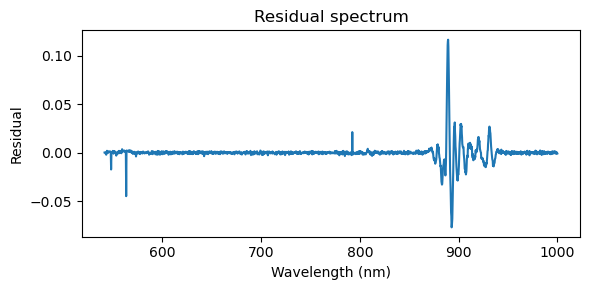

In [47]:
i = 3  # 任意选几条
smooth = savgol_filter(spectra[:, i], 61, 2)
residual = spectra[:, i] - smooth

plt.figure(figsize=(6,3))
plt.plot(wavelength, residual)
plt.xlabel("Wavelength (nm)")
plt.ylabel("Residual")
plt.title("Residual spectrum")
plt.tight_layout()
plt.show()

In [40]:
df_residual = pd.DataFrame({
    "wavelength_nm": wavelength,
    "residual": residual
})

df_residual.to_csv("residual_spectrum_i1.csv", index=False)

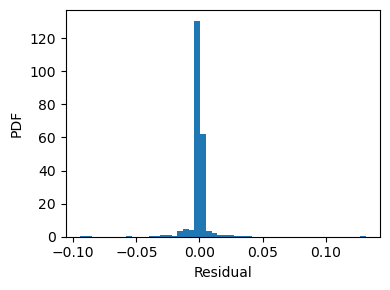

In [41]:
plt.figure(figsize=(4,3))
plt.hist(residual, bins=50, density=True)
plt.xlabel("Residual")
plt.ylabel("PDF")
plt.tight_layout()
plt.show()


In [42]:
snr_list = np.array([
    estimate_snr_spectrum(wavelength, spectra[:, i])[0]
    for i in range(spectra.shape[1])
])


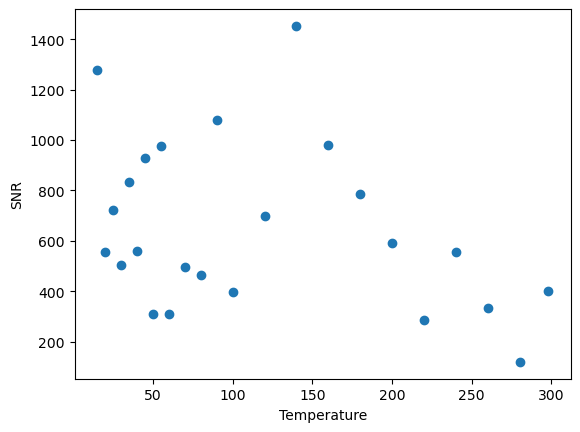

In [43]:
plt.plot(temperatures, snr_list, 'o')
plt.xlabel("Temperature")
plt.ylabel("SNR")
plt.show()

In [44]:
snr_list

array([1278.79689805,  554.65961002,  723.45961144,  504.55584905,
        831.59017493,  559.99055841,  930.3901205 ,  308.77424872,
        975.34865791,  310.19835646,  496.4497419 ,  465.33108021,
       1077.25081562,  398.53273586,  696.83056448, 1452.53858388,
        981.55742247,  785.37220271,  591.5041277 ,  283.62379157,
        553.96567708,  334.79758421,  119.24718253,  399.89857638])

In [45]:
df_snr = pd.DataFrame({
    "Temperature": temperatures,
    "SNR": snr_list,
})

df_snr.to_csv("snr_list_Nd.csv", index=False)


In [46]:
a = 0.00181578 #from the other file of PCA analysis # PC1 vs T slope
df_snr = pd.read_csv("snr_list_Nd.csv")


df_snr["delta_PC1"] = 1 / df_snr["SNR"]
df_snr["delta_T"] = df_snr["delta_PC1"] / abs(a)

df_snr.to_csv("temperature_uncertainty_from_SNR.csv", index=False)

print(df_snr)

    Temperature          SNR  delta_PC1   delta_T
0          15.0  1278.796898   0.000782  0.430661
1          20.0   554.659610   0.001803  0.992911
2          25.0   723.459611   0.001382  0.761242
3          30.0   504.555849   0.001982  1.091510
4          35.0   831.590175   0.001203  0.662258
5          40.0   559.990558   0.001786  0.983459
6          45.0   930.390120   0.001075  0.591932
7          50.0   308.774249   0.003239  1.783593
8          55.0   975.348658   0.001025  0.564647
9          60.0   310.198356   0.003224  1.775404
10         70.0   496.449742   0.002014  1.109332
11         80.0   465.331080   0.002149  1.183518
12         90.0  1077.250816   0.000928  0.511234
13        100.0   398.532736   0.002509  1.381888
14        120.0   696.830564   0.001435  0.790332
15        140.0  1452.538584   0.000688  0.379148
16        160.0   981.557422   0.001019  0.561075
17        180.0   785.372203   0.001273  0.701231
18        200.0   591.504128   0.001691  0.931063


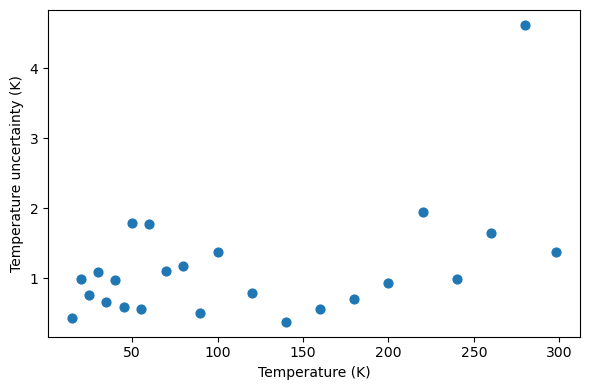

In [48]:
plt.figure(figsize=(6,4))
plt.scatter(
    df_snr["Temperature"],
    df_snr["delta_T"],
    s=40
)
plt.xlabel("Temperature (K)")
plt.ylabel("Temperature uncertainty (K)")
plt.tight_layout()
plt.show()


# resample spectra with different resolutions

In [16]:
wl_new = np.arange(925, 1076, 1)#np.arange(541, 1000, 1)

In [17]:
resampled_spectra = []

for i in range(spectra.shape[1]):
    f = interp1d(
        wavelength,
        spectra[:, i],
        kind="linear",      # or "cubic"
        bounds_error=False,
        fill_value="extrapolate"
    )
    resampled_spectra.append(f(wl_new))

resampled_spectra = np.array(resampled_spectra)  
# shape: (Ntemp, 151)

In [19]:
resampled_spectra.shape

(24, 459)

In [18]:
df_reout = pd.DataFrame(resampled_spectra.T)
df_reout.to_csv("resampled_spectra_Nd.csv", index=False)

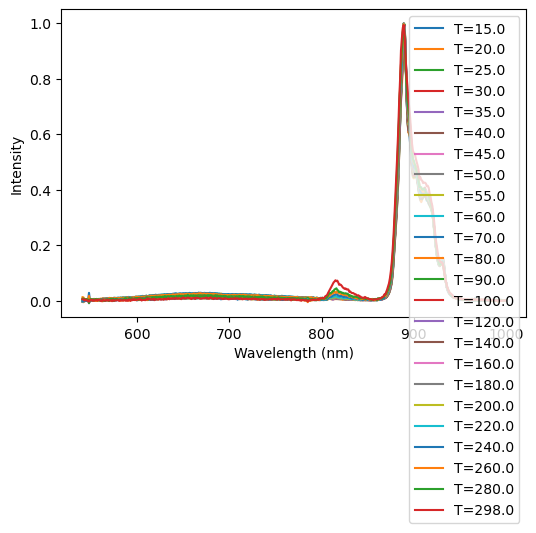

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

for i in range(resampled_spectra.shape[0]):
    plt.plot(wl_new, resampled_spectra[i], label=f"T={temperatures[i]}")

plt.xlabel("Wavelength (nm)")
plt.ylabel("Intensity")
plt.legend()
plt.show()

# simulated_spectra_realistic_noise

In [5]:
temps_unique = np.unique(temperatures)
cols_per_temp = {T: np.where(temperatures==T)[0] for T in temps_unique}

noise_std_orig = np.zeros((len(temps_unique), spectra.shape[0]))

for i, T in enumerate(temps_unique):
    cols_idx = cols_per_temp[T]
    noise_std_orig[i] = spectra[:, cols_idx].std(axis=1)  # shape = (Nwl_orig,)


In [10]:
from scipy.interpolate import interp1d

noise_std_resampled = np.zeros((len(temps_unique), len(wl_new)))

for i in range(len(temps_unique)):
    f_std = interp1d(
        wavelength,          
        noise_std_orig[i],   
        kind="linear",
        bounds_error=False,
        fill_value="extrapolate"
    )
    noise_std_resampled[i] = f_std(wl_new)


In [15]:
n_sim = 200
simulated_spectra = []

for i in range(len(temps_unique)):
    sims = []
    template = resampled_spectra[i]  # 重采样干净光谱
    for j in range(n_sim):
        noise = np.random.normal(0, noise_std_resampled[i])
        sims.append(template + noise)
    simulated_spectra.append(sims)

simulated_spectra = np.array(simulated_spectra)  # shape = (Ntemp, n_sim, Nwl_resampled)


In [16]:

data_out = {"wavelength": wl_new}
for i, T in enumerate(temps_unique):
    for j in range(n_sim):
        col_name = f"T{int(T)}_sim{j+1}"
        data_out[col_name] = simulated_spectra[i, j]

df_out = pd.DataFrame(data_out)
df_out.to_csv("simulated_spectra_realistic_noise.csv", index=False)


In [17]:
df_out.shape

(151, 4801)

# simulate with only noise

In [21]:
n_sim = 200       
sigma = 0.01

def add_intensity_noise(spectrum, sigma=0.01):

    noise = np.random.normal(0, sigma * np.abs(spectrum))
    return spectrum + noise

In [22]:
simulated_spectra = []

for spec in resampled_spectra:  # 遍历每个温度
    sims = []
    for _ in range(n_sim):
        sims.append(add_intensity_noise(spec, sigma=sigma))
    simulated_spectra.append(sims)

# 转成 numpy array
simulated_spectra = np.array(simulated_spectra)  

In [23]:
import pandas as pd

data = {
    "wavelength": wl_new
}

for i, T in enumerate(temperatures):
    for j in range(simulated_spectra.shape[1]):  # 200
        col_name = f"T{T}_sim{j+1}"
        data[col_name] = simulated_spectra[i, j]

df_out = pd.DataFrame(data)
df_out.to_csv("simulated_spectra.csv", index=False)


# plot

In [24]:
df_out.shape

(459, 4801)

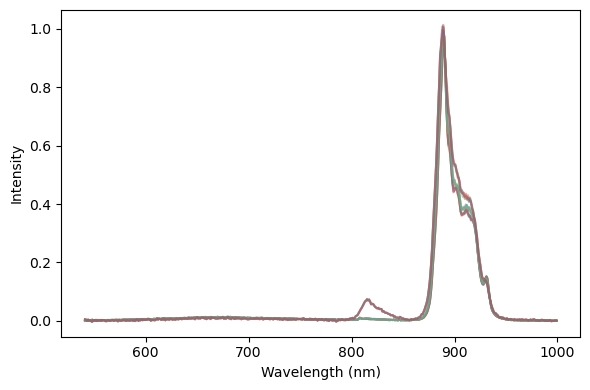

In [25]:
import matplotlib.pyplot as plt

# 想看的温度（按你的 columns 实际名字来）
T_list = [temperatures[0], temperatures[15], temperatures[23]]

n_show = 5  # 每个温度画几条

plt.figure(figsize=(6, 4))

for T in T_list:
    cols = [c for c in df_out.columns if c.startswith(f"T{T}_sim")][:n_show]
    for c in cols:
        plt.plot(
            df_out["wavelength"],
            df_out[c],
            alpha=0.4,
            label=f"T={T}" if c == cols[0] else None
        )

plt.xlabel("Wavelength (nm)")
plt.ylabel("Intensity")
#plt.legend()
plt.tight_layout()
plt.show()
